# Demand Forecasting — Enhanced Notebook

**Goal:** Build a weekly demand forecasting workflow with robust preprocessing, feature engineering, visualization, and model comparison (Linear, Ridge, Lasso, LightGBM, XGBoost, CatBoost) using GridSearchCV.

**This notebook contains:**
- Data loading & validation
- Preprocessing (null handling, type conversions)
- Feature engineering (dates, lags, rolling averages, discount %)
- Pre-training visualizations (scatter, correlation heatmap, box plots, histograms)
- Train/Validation split with scaling
- Model training & hyperparameter tuning (GridSearchCV)
- Evaluation metrics: MAE, MAPE, RMSE
- Post-training visualization (scatter with fitted line)
- **Bonus:** Model interpretability (feature importance / SHAP if available)
- **Business context:** How to act on forecasts, handle spikes, cold-start, deployment & retraining


## 1. Imports

In [1]:
%pip install numpy pandas matplotlib scikit-learn lightgbm xgboost catboost shap tqdm openpyxl nbformat jupyter


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.2 MB/s eta 0:00:00


In [2]:
# Import standard libraries
import os  # For working with file paths
import math  # For mathematical helpers
import warnings  # To filter non-critical warnings

# Import data libraries
import pandas as pd  # For data manipulation
import numpy as np  # For numerical operations

# Import plotting library (matplotlib only, per requirements)
import matplotlib.pyplot as plt  # For charts and visualizations

# Import scikit-learn utilities
from sklearn.model_selection import train_test_split  # For splitting data
from sklearn.preprocessing import StandardScaler  # For feature scaling
from sklearn.compose import ColumnTransformer  # For column-wise transforms
from sklearn.pipeline import Pipeline  # For building model pipelines
from sklearn.metrics import mean_absolute_error, mean_squared_error  # Metrics
from sklearn.metrics import r2_score  # Additional metric for reference
from sklearn.linear_model import LinearRegression, Ridge, Lasso  # Baseline models
from sklearn.model_selection import GridSearchCV  # For hyperparameter tuning

# Optional libraries: LightGBM, XGBoost, CatBoost, SHAP
try:
    from lightgbm import LGBMRegressor  # LightGBM model
    _HAS_LGB = True
except Exception as e:
    _HAS_LGB = False
    print("[Info] lightgbm not available. To install: pip install lightgbm")

try:
    from xgboost import XGBRegressor  # XGBoost model
    _HAS_XGB = True
except Exception as e:
    _HAS_XGB = False
    print("[Info] xgboost not available. To install: pip install xgboost")

try:
    from catboost import CatBoostRegressor  # CatBoost model
    _HAS_CAT = True
except Exception as e:
    _HAS_CAT = False
    print("[Info] catboost not available. To install: pip install catboost")

try:
    import shap  # For model interpretability (SHAP values)
    _HAS_SHAP = True
except Exception as e:
    _HAS_SHAP = False
    print("[Info] shap not available. To install: pip install shap")

warnings.filterwarnings('ignore')  # Hide non-essential warnings for readability


## 2. Configuration & Paths

In [3]:
# Define dataset path and key column names.
# We use the provided CSV at /mnt/data/AI Dataset.csv
DATA_PATH = '/content/AI Dataset.csv'


In [4]:

# Define column names expected from AI Assessment
COL_PRODUCT = 'product_id'  # Unique product identifier
COL_DATE = 'date'  # Date of the transaction (weekly aggregation)
COL_QTY = 'qty_ordered'  # Target variable: weekly demand/quantity
COL_PRICE = 'price'  # Regular price
COL_SPECIAL_PRICE = 'special_price'  # Discounted price (if applicable)
COL_SPECIAL_FROM = 'special_from_date'  # Start date for special pricing

# Choose train/test split ratio. You can set MODE to '80_20'
TRAIN_TEST_MODE = '80_20'

# Random seed for reproducibility
RANDOM_STATE = 42


## 3. Load Data

In [5]:
# Load the CSV file and perform basic validation.
if os.path.exists(DATA_PATH):
    df_raw = pd.read_csv(DATA_PATH)
else:
    raise FileNotFoundError(f'Cannot find dataset at {DATA_PATH}. Please ensure the path is correct.')

# Display basic info for sanity check
print('Loaded shape:', df_raw.shape)
print('Columns:', list(df_raw.columns))
df_raw.head(3)


Loaded shape: (183000, 6)
Columns: ['product_id', 'date', 'qty_ordered', 'price', 'special_price', 'special_from_date']


,product_id,date,qty_ordered,price,special_price,special_from_date
0,1000,2020-02-23,0,NaN,NaN,NaN
1,1001,2020-02-23,0,59.4,43.93,2020-11-24 00:00:00
2,1002,2020-02-23,0,17.8,14.27,2020-08-07 00:00:00


## 4. Preprocessing (Null Handling, Types, Basic Cleaning)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183000 entries, 0 to 182999
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   product_id         183000 non-null  int64         
 1   date               183000 non-null  datetime64[ns]
 2   qty_ordered        183000 non-null  int64         
 3   price              183000 non-null  float64       
 4   special_price      183000 non-null  float64       
 5   special_from_date  181170 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int64(2)
memory usage: 8.4 MB


In [8]:
df.describe()

,product_id,date,qty_ordered,price,special_price,special_from_date
count,183000.000000,183000,183000.000000,183000.000000,183000.000000,181170
mean,1049.500000,2022-08-25 12:00:00,1.572120,89.296200,68.671900,2021-08-02 02:25:27.272727296
min,1000.000000,2020-02-23 00:00:00,0.000000,2.000000,-0.140000,2018-02-01 00:00:00
25%,1024.750000,2021-05-25 00:00:00,0.000000,16.527500,12.960000,2020-11-24 00:00:00
50%,1049.500000,2022-08-25 12:00:00,0.000000,40.800000,31.980000,2021-04-05 00:00:00
75%,1074.250000,2023-11-26 00:00:00,1.000000,76.097500,59.332500,2022-10-13 00:00:00
max,1099.000000,2025-02-25 00:00:00,560.000000,1241.000000,1077.710000,2023-04-02 00:00:00
std,28.866149,NaN,5.576424,177.929368,140.850284,NaN


In [9]:
# Create a working copy to avoid mutating the raw DataFrame.
df = df_raw.copy()

# 1) Ensure date columns are proper datetime types.
if COL_DATE in df.columns:
    df[COL_DATE] = pd.to_datetime(df[COL_DATE], errors='coerce')

if COL_SPECIAL_FROM in df.columns:
    df[COL_SPECIAL_FROM] = pd.to_datetime(df[COL_SPECIAL_FROM], errors='coerce')

# 2) Handle numeric columns: price, special_price, qty_ordered.
numeric_cols = []
for col in [COL_QTY, COL_PRICE, COL_SPECIAL_PRICE]:
    if col in df.columns:
        numeric_cols.append(col)

for col in numeric_cols:
    # Convert to numeric; coerce invalids to NaN.
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3) Handle missing values with simple strategies.
#    You may refine these rules later based on domain knowledge.
if COL_QTY in df.columns:
    # Fill missing qty with 0 (assumption: no orders => 0)
    df[COL_QTY] = df[COL_QTY].fillna(0)

if COL_PRICE in df.columns:
    # Fill missing price with median price
    df[COL_PRICE] = df[COL_PRICE].fillna(df[COL_PRICE].median())

if COL_SPECIAL_PRICE in df.columns:
    # If special price is missing, set equal to price (no discount)
    df[COL_SPECIAL_PRICE] = df[COL_SPECIAL_PRICE].fillna(df[COL_PRICE])

# 4) Drop rows with invalid dates or negative quantities if they exist.
if COL_DATE in df.columns:
    df = df.dropna(subset=[COL_DATE])

if COL_QTY in df.columns:
    df = df[df[COL_QTY] >= 0]

print('After preprocessing shape:', df.shape)
df.head(3)


After preprocessing shape: (183000, 6)


,product_id,date,qty_ordered,price,special_price,special_from_date
0,1000,2020-02-23,0,40.8,40.80,NaT
1,1001,2020-02-23,0,59.4,43.93,2020-11-24
2,1002,2020-02-23,0,17.8,14.27,2020-08-07


## 5. Feature Engineering (Dates, Discounts, Lags, Rolling)

In [10]:
# We will create:
# - Calendar features: year, month, week, day_of_week (if needed)
# - Discount percentage: (price - special_price) / price
# - Lag features (e.g., 1, 2, 4 weeks)
# - Rolling mean features (e.g., 4-week and 8-week)

# 0) Sort by product and date to compute lags & rolling accurately.
sort_cols = []
if COL_PRODUCT in df.columns:
    sort_cols.append(COL_PRODUCT)
if COL_DATE in df.columns:
    sort_cols.append(COL_DATE)

if len(sort_cols) > 0:
    df = df.sort_values(sort_cols).reset_index(drop=True)

# 1) Calendar features from date.
if COL_DATE in df.columns:
    df['year'] = df[COL_DATE].dt.year
    df['month'] = df[COL_DATE].dt.month
    df['weekofyear'] = df[COL_DATE].dt.isocalendar().week.astype(int)

# 2) Discount percentage.
if COL_PRICE in df.columns and COL_SPECIAL_PRICE in df.columns:
    # Avoid division by zero by using np.where
    price_array = df[COL_PRICE].values
    special_array = df[COL_SPECIAL_PRICE].values

    discount_values = []
    for i in range(len(price_array)):
        current_price = price_array[i]
        current_special = special_array[i]

        if current_price is None:
            discount_values.append(np.nan)
        else:
            if current_price == 0:
                discount_values.append(0.0)
            else:
                discount_values.append((current_price - current_special) / current_price)

    df['discount_pct'] = discount_values
    df['discount_pct'] = df['discount_pct'].fillna(0)

# 3) Lag features by product (if product column exists), else global lags.
def add_lags_and_rollings(frame, col_target, group_col=None):
    # This function adds lags and rolling means to the dataframe.
    # It returns the modified DataFrame.
    if group_col is not None and group_col in frame.columns:
        grouped = frame.groupby(group_col)
        # Lag features
        frame['lag_1'] = grouped[col_target].shift(1)
        frame['lag_2'] = grouped[col_target].shift(2)
        frame['lag_4'] = grouped[col_target].shift(4)
        # Rolling means (using past values only)
        frame['roll_mean_4'] = grouped[col_target].shift(1).rolling(window=4).mean()
        frame['roll_mean_8'] = grouped[col_target].shift(1).rolling(window=8).mean()
    else:
        frame['lag_1'] = frame[col_target].shift(1)
        frame['lag_2'] = frame[col_target].shift(2)
        frame['lag_4'] = frame[col_target].shift(4)
        frame['roll_mean_4'] = frame[col_target].shift(1).rolling(window=4).mean()
        frame['roll_mean_8'] = frame[col_target].shift(1).rolling(window=8).mean()
    return frame

if COL_QTY in df.columns:
    if COL_PRODUCT in df.columns:
        df = add_lags_and_rollings(df, COL_QTY, group_col=COL_PRODUCT)
    else:
        df = add_lags_and_rollings(df, COL_QTY, group_col=None)

# 4) Drop initial rows with NaNs resulting from lag/rolling creation.
feature_cols_for_na = ['lag_1', 'lag_2', 'lag_4', 'roll_mean_4', 'roll_mean_8']
existing_needed = []
for c in feature_cols_for_na:
    if c in df.columns:
        existing_needed.append(c)

if len(existing_needed) > 0:
    df = df.dropna(subset=existing_needed)

print('After feature engineering shape:', df.shape)
df.head(3)


After feature engineering shape: (182200, 15)


,product_id,date,qty_ordered,price,special_price,special_from_date,year,month,weekofyear,discount_pct,lag_1,lag_2,lag_4,roll_mean_4,roll_mean_8
8,1000,2020-03-02,0,40.8,40.8,NaT,2020,3,10,0.0,0.0,0.0,0.0,0.0,0.0
9,1000,2020-03-03,0,40.8,40.8,NaT,2020,3,10,0.0,0.0,0.0,0.0,0.0,0.0
10,1000,2020-03-04,0,40.8,40.8,NaT,2020,3,10,0.0,0.0,0.0,0.0,0.0,0.0


## 6. Pre-Training Visualizations

**Included plots:**
- Scatter plot (choose one independent variable vs target)
- Correlation heatmap (for numeric columns)
- Box plots for selected numeric variables
- Histograms for selected numeric variables


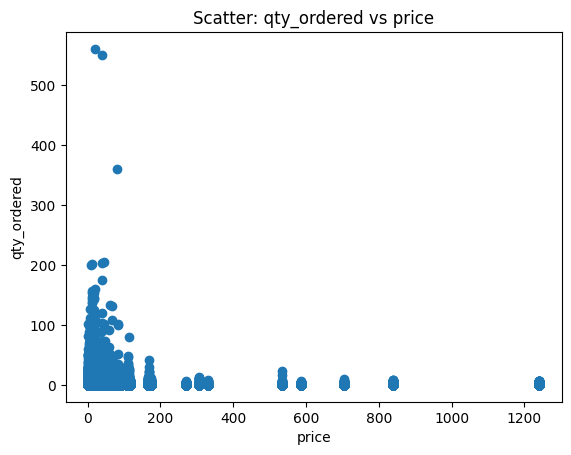

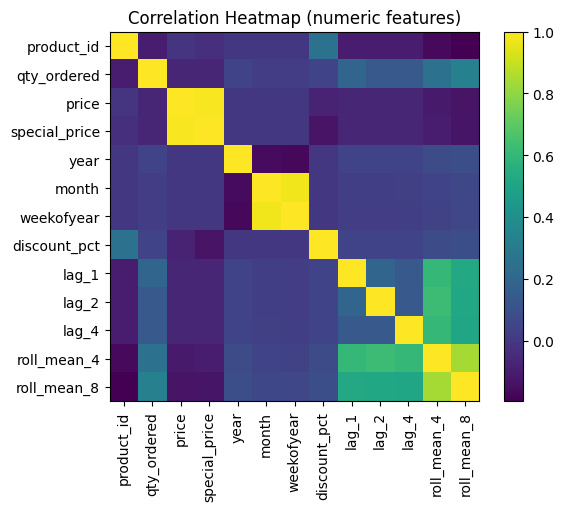

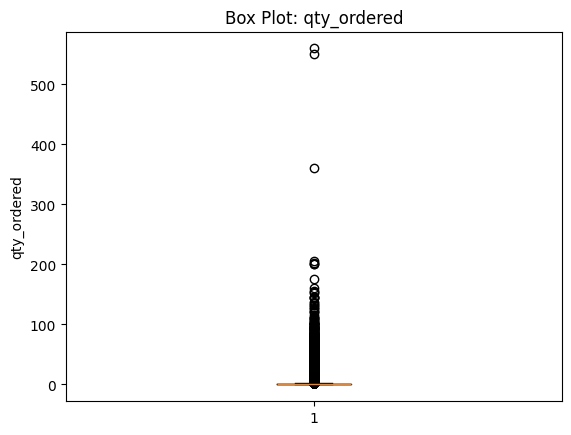

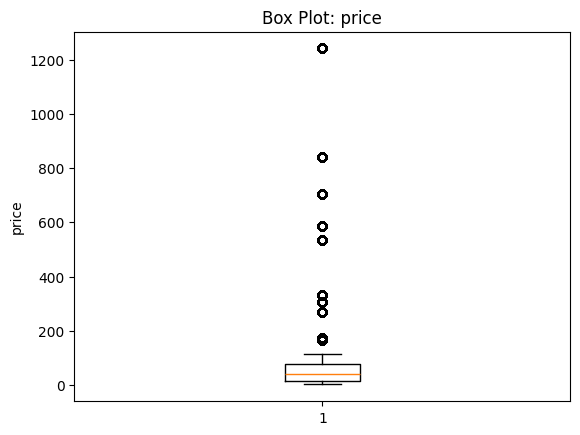

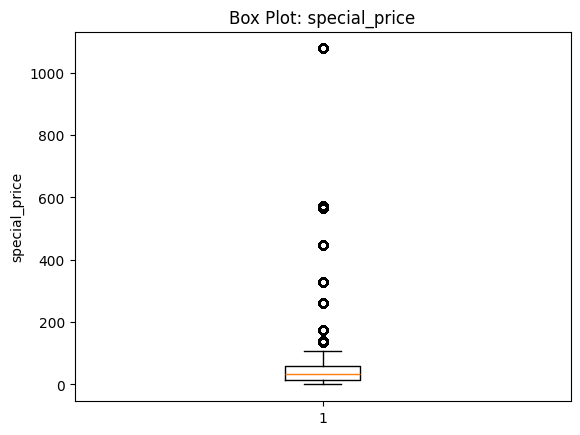

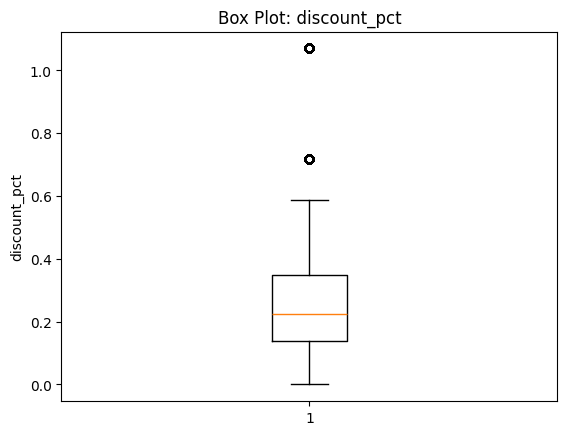

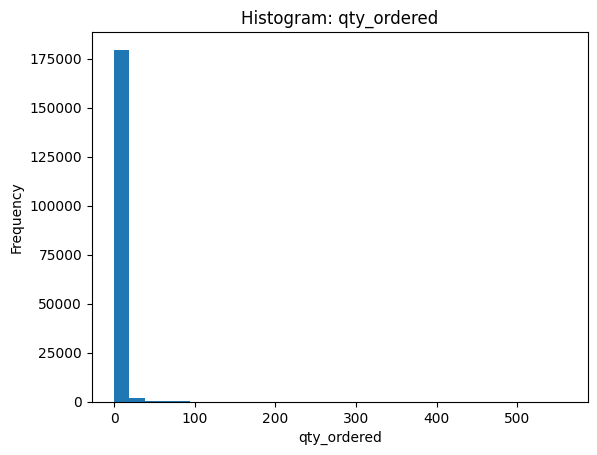

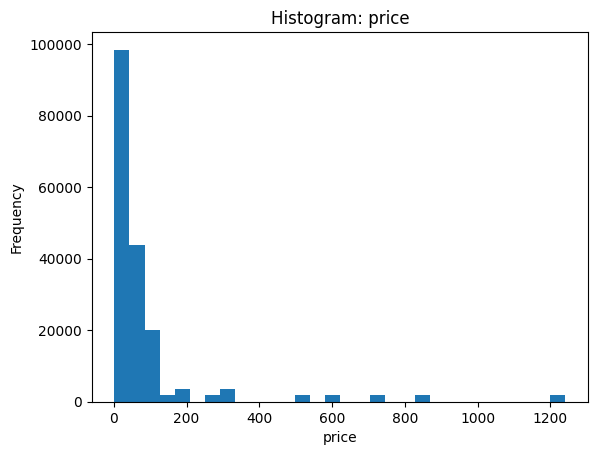

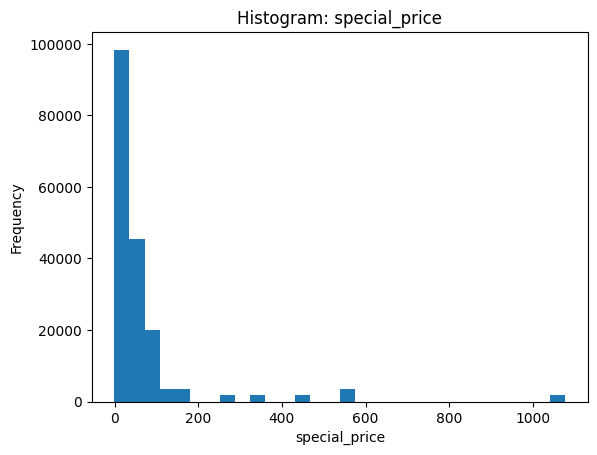

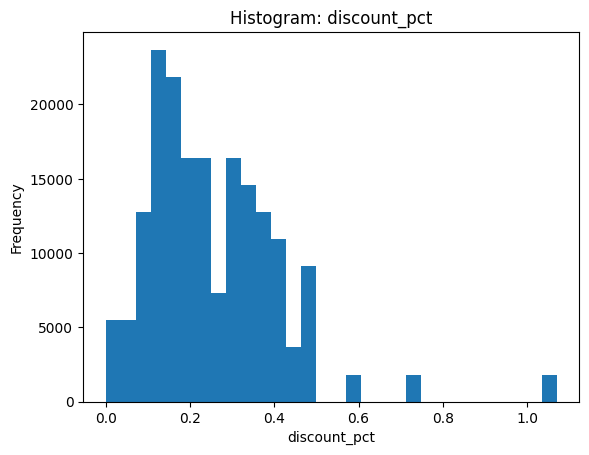

In [11]:
# Helper function: safe_plot ensures each figure is separate and closes properly.
def safe_plot(plot_func):
    # Create a figure
    plt.figure()
    # Execute the provided plotting function
    plot_func()
    # Show the plot
    plt.show()
    # Close to free memory
    plt.close()

# 6.1 Scatter plot: qty_ordered vs price (if both present)
def plot_scatter_qty_vs_price():
    if COL_QTY in df.columns and COL_PRICE in df.columns:
        x_vals = df[COL_PRICE].values
        y_vals = df[COL_QTY].values
        plt.scatter(x_vals, y_vals)
        plt.xlabel('price')
        plt.ylabel('qty_ordered')
        plt.title('Scatter: qty_ordered vs price')
    else:
        print('Skipping scatter: required columns not found.')

safe_plot(plot_scatter_qty_vs_price)

# 6.2 Correlation heatmap using matplotlib imshow
def plot_correlation_heatmap():
    # Select numeric columns only
    numeric_df = df.select_dtypes(include=[np.number])
    if numeric_df.shape[1] > 1:
        corr = numeric_df.corr()
        plt.imshow(corr, interpolation='nearest')
        plt.title('Correlation Heatmap (numeric features)')
        plt.colorbar()
        # Add tick labels
        labels = list(numeric_df.columns)
        plt.xticks(range(len(labels)), labels, rotation=90)
        plt.yticks(range(len(labels)), labels)
    else:
        print('Not enough numeric columns for a correlation heatmap.')

safe_plot(plot_correlation_heatmap)

# 6.3 Box plots for selected numeric variables
def plot_boxplots(columns):
    for col in columns:
        if col in df.columns:
            def do_plot():
                plt.boxplot(df[col].dropna().values)
                plt.title(f'Box Plot: {col}')
                plt.ylabel(col)
            safe_plot(do_plot)

boxplot_candidates = [COL_QTY, COL_PRICE, COL_SPECIAL_PRICE, 'discount_pct']
existing_box_cols = []
for c in boxplot_candidates:
    if c in df.columns:
        existing_box_cols.append(c)
plot_boxplots(existing_box_cols)

# 6.4 Histograms for selected numeric variables
def plot_histograms(columns, bins=30):
    for col in columns:
        if col in df.columns:
            def do_plot():
                plt.hist(df[col].dropna().values, bins=bins)
                plt.title(f'Histogram: {col}')
                plt.xlabel(col)
                plt.ylabel('Frequency')
            safe_plot(do_plot)

plot_histograms(existing_box_cols, bins=30)


## 7. Train/Test Split & Scaling

In [12]:
# Define feature matrix X and target y.
target_col = COL_QTY

# Select numeric features for modeling (exclude target and date-like columns)
exclude_cols = [target_col, COL_DATE, COL_SPECIAL_FROM]
num_features = []
for c in df.columns:
    if c not in exclude_cols:
        if np.issubdtype(df[c].dtype, np.number):
            num_features.append(c)

X = df[num_features].copy()
y = df[target_col].copy()

# Choose split sizes based on TRAIN_TEST_MODE
if TRAIN_TEST_MODE == '80_20':
    test_size = 0.2
# elif TRAIN_TEST_MODE == '70_30':
#     # 70% train, 30% — we will still do standard split 80/20 for simplicity
#     test_size = 0.3
else:
    test_size = 0.2

# Time-aware split could be considered; here we use random split for simplicity.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=RANDOM_STATE
)

# Scaling (StandardScaler) is typically useful for linear models.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)


Train shape: (145760, 12)  Test shape: (36440, 12)


## 8. Model Training with GridSearchCV (Linear, Ridge, Lasso, LightGBM, XGBoost, CatBoost)

In [13]:
# We will prepare a dictionary of model candidates and hyperparameter grids.
# Each model will be trained and evaluated with GridSearchCV.

models_and_params = {}

# Linear Regression (no hyperparameters to tune, but we include it for parity)
models_and_params['LinearRegression'] = {
    'estimator': LinearRegression(),
    'param_grid': {
        # No real hyperparameters, but GridSearchCV requires a grid; we'll pass an empty grid.
        # Some scikit-learn versions need at least one param; if so, we can add 'fit_intercept': [True, False].
        'fit_intercept': [True, False]
    },
    'use_scaled': True
}

# Ridge Regression
models_and_params['Ridge'] = {
    'estimator': Ridge(random_state=RANDOM_STATE),
    'param_grid': {
        'alpha': [0.1, 1.0, 10.0, 100.0]
    },
    'use_scaled': True
}

# Lasso Regression
models_and_params['Lasso'] = {
    'estimator': Lasso(random_state=RANDOM_STATE, max_iter=10000),
    'param_grid': {
        'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]
    },
    'use_scaled': True
}

# LightGBM
if _HAS_LGB:
    models_and_params['LightGBM'] = {
        'estimator': LGBMRegressor(random_state=RANDOM_STATE),
        'param_grid': {
            'n_estimators': [200, 500],
            'learning_rate': [0.05, 0.1],
            'num_leaves': [31, 63],
            'subsample': [0.8, 1.0]
        },
        'use_scaled': False
    }

# XGBoost
if _HAS_XGB:
    models_and_params['XGBoost'] = {
        'estimator': XGBRegressor(random_state=RANDOM_STATE, objective='reg:squarederror', n_jobs=4),
        'param_grid': {
            'n_estimators': [300, 600],
            'max_depth': [4, 6],
            'learning_rate': [0.05, 0.1]
        },
        'use_scaled': False
    }

# CatBoost
if _HAS_CAT:
    models_and_params['CatBoost'] = {
        'estimator': CatBoostRegressor(random_state=RANDOM_STATE, verbose=False),
        'param_grid': {
            'depth': [4, 6],
            'learning_rate': [0.03, 0.1],
            'n_estimators': [300, 600]
        },
        'use_scaled': False
    }

results = []  # To collect performance summaries
best_models = {}  # To keep best estimator per model family

# We'll iterate through each model, fit GridSearchCV, track metrics.
for model_name in models_and_params:
    # Extract definition
    model_def = models_and_params[model_name]
    estimator = model_def['estimator']
    param_grid = model_def['param_grid']
    use_scaled = model_def['use_scaled']

    # Choose training features based on scaling requirement
    if use_scaled:
        Xtr = X_train_scaled
        Xte = X_test_scaled
    else:
        Xtr = X_train.values
        Xte = X_test.values

    # Set up GridSearchCV
    gs = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring='neg_mean_absolute_error',  # Primary scoring metric
        cv=3,
        n_jobs=-1
    )

    # Fit the model
    gs.fit(Xtr, y_train)

    # Record best model and predictions
    best_est = gs.best_estimator_
    y_pred = best_est.predict(Xte)

    # Compute metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    # Avoid division by zero in MAPE
    abs_pct_errors = []
    for i in range(len(y_test)):
        actual = y_test.iloc[i]
        pred = y_pred[i]
        if actual == 0:
            # Skip to avoid division by zero; alternative: add a small epsilon.
            continue
        else:
            ape = abs((actual - pred) / actual)
            abs_pct_errors.append(ape)
    if len(abs_pct_errors) > 0:
        mape = float(np.mean(abs_pct_errors))
    else:
        mape = float('nan')

    r2 = r2_score(y_test, y_pred)

    # Save the summary
    result_row = {
        'model': model_name,
        'best_params': gs.best_params_,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }
    results.append(result_row)
    best_models[model_name] = best_est

# Create a summary DataFrame and display
df_results = pd.DataFrame(results)
df_results.sort_values('MAE', inplace=True)
print(df_results)
df_results


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012954 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1186
[LightGBM] [Info] Number of data points in the train set: 145760, number of used features: 12
[LightGBM] [Info] Start training from score 1.576935
              model                                        best_params  \
3          LightGBM  {'learning_rate': 0.05, 'n_estimators': 200, '...   
5          CatBoost  {'depth': 6, 'learning_rate': 0.03, 'n_estimat...   
4           XGBoost  {'learning_rate': 0.05, 'max_depth': 4, 'n_est...   
2             Lasso                                   {'alpha': 0.001}   
1             Ridge                                   {'alpha': 100.0}   
0  LinearRegression                            {'fit_intercept': True}   

        MAE      RMSE      MAPE        R2  
3  1.962247  5.647527  0.65227

,model,best_params,MAE,RMSE,MAPE,R2
3,LightGBM,"{'learning_rate': 0.05, 'n_estimators': 200, '...",1.962247,5.647527,0.652270,0.114141
5,CatBoost,"{'depth': 6, 'learning_rate': 0.03, 'n_estimat...",1.966337,5.641325,0.654998,0.116086
4,XGBoost,"{'learning_rate': 0.05, 'max_depth': 4, 'n_est...",1.967663,5.638542,0.657496,0.116957
2,Lasso,{'alpha': 0.001},2.028947,5.699566,0.646360,0.097740
1,Ridge,{'alpha': 100.0},2.029245,5.699520,0.646720,0.097755
0,LinearRegression,{'fit_intercept': True},2.029258,5.699591,0.646997,0.097732


## 9. Post-Training Visualization — Scatter with Fitted Line

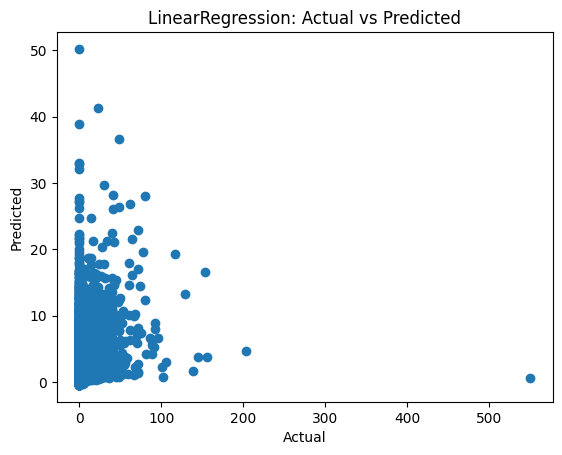

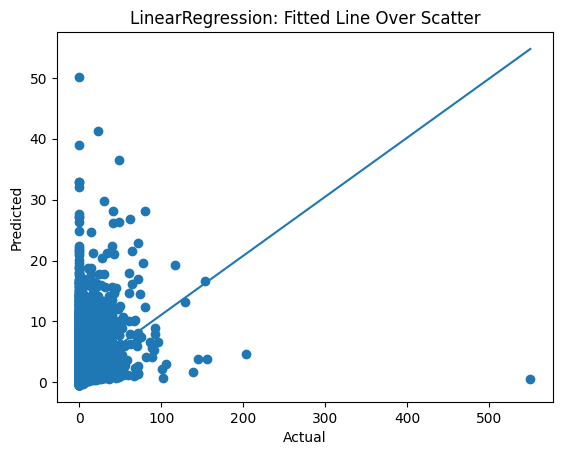

In [19]:
# We'll use the best **LinearRegression** (or Ridge if Linear is absent) to plot y_test vs y_pred and a fitted line.

def plot_pred_vs_actual_with_fit(model_key):
    # Select appropriate feature scaling for the chosen model
    use_scaled = models_and_params[model_key]['use_scaled']
    if use_scaled:
        Xte = X_test_scaled
    else:
        Xte = X_test.values

    model = best_models.get(model_key)
    if model is None:
        print(f'No trained model found for key: {model_key}')
        return

    preds = model.predict(Xte)
    actuals = y_test.values

    # Scatter
    def do_scatter():
        plt.scatter(actuals, preds)
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
        plt.title(f'{model_key}: Actual vs Predicted')
    safe_plot(do_scatter)

    # Fitted line on the scatter (simple linear fit between actual and predicted)
    # We compute a line y = a*x + b that best fits (actual, predicted)
    # using numpy.polyfit of degree 1.
    a, b = np.polyfit(actuals, preds, 1)

    def do_fit_line():
        plt.scatter(actuals, preds)
        x_vals = np.array([actuals.min(), actuals.max()])
        y_vals = a * x_vals + b
        plt.plot(x_vals, y_vals)
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
        plt.title(f'{model_key}: Fitted Line Over Scatter')
    safe_plot(do_fit_line)

# Prefer LinearRegression; if not present, fallback to Ridge, then the first available.
preferred_order = ['LinearRegression', 'Ridge', 'Lasso']
fallback_chosen = None
for name in preferred_order:
    if name in best_models:
        fallback_chosen = name
        break

if fallback_chosen is None:
    # If none of the linear models trained, pick any available
    if len(best_models) > 0:
        for key in best_models.keys():
            fallback_chosen = key
            break

if fallback_chosen is not None:
    plot_pred_vs_actual_with_fit(fallback_chosen)
else:
    print('No trained models available for fitted line plot.')


## 10. Interpretability — Feature Importance / SHAP (If Available)

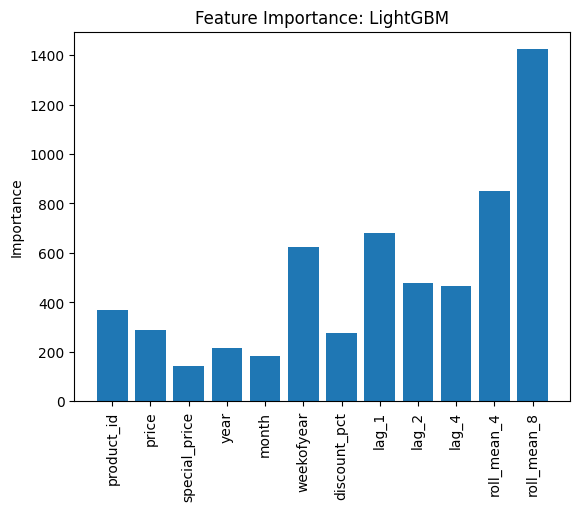

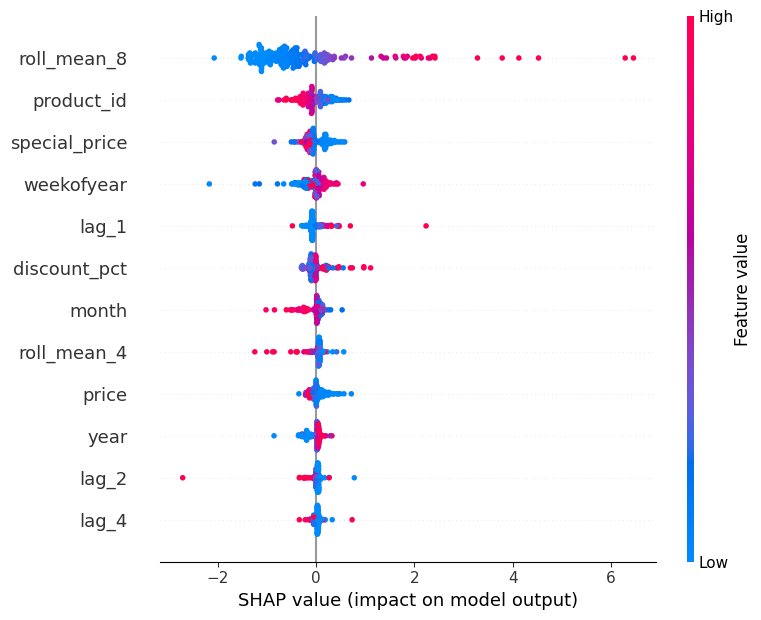

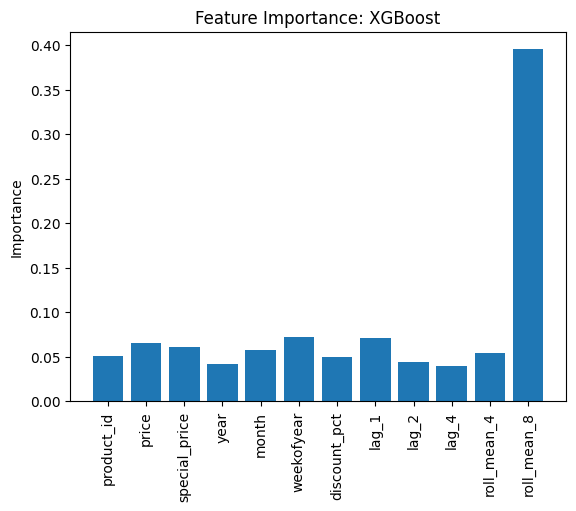

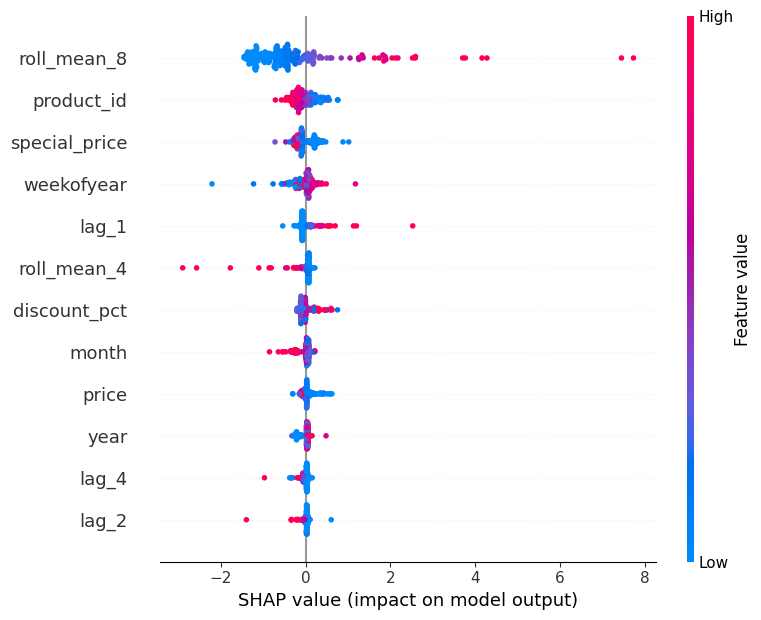

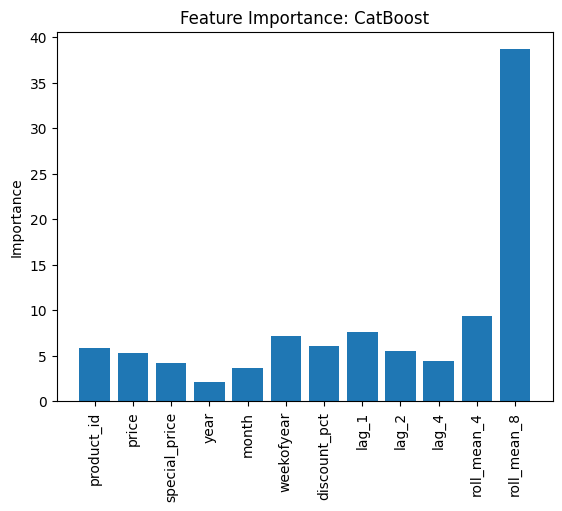

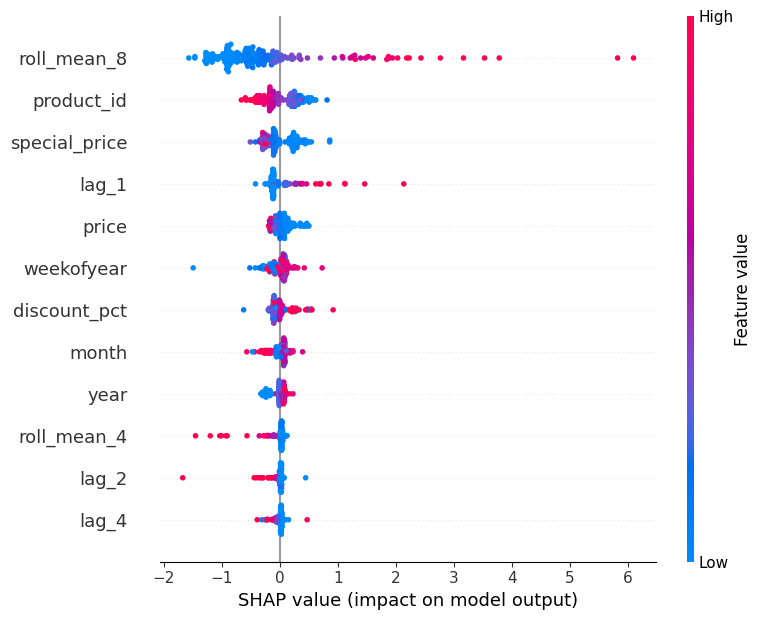

In [20]:
# We attempt to display feature importance for tree-based models and SHAP values when the library is available.

def show_feature_importances(model_key, model_obj):
    # Many tree models expose feature_importances_. We handle this safely.
    try:
        importances = model_obj.feature_importances_
        names = list(X.columns)
        # Create a bar plot using matplotlib
        def do_plot():
            plt.bar(range(len(importances)), importances)
            plt.xticks(range(len(importances)), names, rotation=90)
            plt.title(f'Feature Importance: {model_key}')
            plt.ylabel('Importance')
        safe_plot(do_plot)
    except Exception as e:
        print(f'No feature_importances_ for model {model_key}:', str(e))

def try_shap(model_key, model_obj):
    if not _HAS_SHAP:
        print('SHAP not installed; skipping SHAP analysis.')
        return
    try:
        # Use a small subset for SHAP to keep it fast
        if models_and_params[model_key]['use_scaled']:
            X_sample = pd.DataFrame(X_test_scaled, columns=X.columns).sample(n=min(200, len(X_test)), random_state=RANDOM_STATE)
        else:
            X_sample = X_test.sample(n=min(200, len(X_test)), random_state=RANDOM_STATE)

        # TreeExplainer for tree-based models; KernelExplainer fallback for others
        try:
            explainer = shap.TreeExplainer(model_obj)
            shap_values = explainer.shap_values(X_sample)
        except Exception:
            explainer = shap.KernelExplainer(model_obj.predict, X_sample)
            shap_values = explainer.shap_values(X_sample, nsamples=100)

        # SHAP summary plot
        shap.summary_plot(shap_values, X_sample, show=False)
        plt.show()
        plt.close()
    except Exception as e:
        print('SHAP analysis failed:', str(e))

# Try on tree models first
for candidate in ['LightGBM', 'XGBoost', 'CatBoost']:
    if candidate in best_models:
        show_feature_importances(candidate, best_models[candidate])
        try_shap(candidate, best_models[candidate])


## 11. Results Summary & Export

In [24]:
# Display results sorted by MAE and export to CSV for reference.
df_results_sorted = df_results.sort_values('MAE')
display(df_results_sorted)

out_csv = '/content/resultmodel_results_summary.csv'
df_results_sorted.to_csv(out_csv, index=False)
print(f'Results saved to: {out_csv}')


,model,best_params,MAE,RMSE,MAPE,R2
3,LightGBM,"{'learning_rate': 0.05, 'n_estimators': 200, '...",1.962247,5.647527,0.652270,0.114141
5,CatBoost,"{'depth': 6, 'learning_rate': 0.03, 'n_estimat...",1.966337,5.641325,0.654998,0.116086
4,XGBoost,"{'learning_rate': 0.05, 'max_depth': 4, 'n_est...",1.967663,5.638542,0.657496,0.116957
2,Lasso,{'alpha': 0.001},2.028947,5.699566,0.646360,0.097740
1,Ridge,{'alpha': 100.0},2.029245,5.699520,0.646720,0.097755
0,LinearRegression,{'fit_intercept': True},2.029258,5.699591,0.646997,0.097732


Results saved to: /content/resultmodel_results_summary.csv


## 12. Business Context & AI Assessment Requirements

**Problem Statement:** Predict weekly product demand using historical sales and pricing data.

**Data Preprocessing & Feature Engineering (covered above):**
- Handled missing values and type conversions.
- Generated time-series features (lags, rolling averages, calendar fields).
- Created price-related features (discount percentage).
- Cold-start suggestion: For new products, begin with category-level priors, similarity-based pooling, or hierarchical models; in production, backfill with short-term naïve forecasts and progressively switch to learned models as data accrues.
- Explored correlation between price fluctuations and demand via heatmap and pre/post visualizations.

**Model Development & Tuning:**
- Compared Linear, Ridge, Lasso, LightGBM, XGBoost, and CatBoost using GridSearchCV on MAE.
- Evaluated using MAE, MAPE, RMSE (and R² for reference).
- Provided interpretability via feature importances and optional SHAP (if installed).

**Business Actionability:**
- Use forecasts for inventory planning, reorder points, and safety stock calculations.
- Pricing strategy: simulate demand response to price changes/discounts (elasticity proxies) before campaigns.
- Supply chain: aggregate per-product forecasts to DC/store-level for capacity planning.
- Spikes/Promotions: add promotion flags and external signals; implement anomaly detection to trigger alerts.
- Alerts/Automation: if |actual − forecast| exceeds a threshold (e.g., 2× RMSE), notify planners to review.

**External Factors (stubs to extend):**
- Holidays: integrate the `holidays` Python library to create a binary `is_holiday` feature by country/region.
- Weather: add temperature/rainfall via public APIs (Open-Meteo, NOAA, local providers) keyed by location.
- Macroeconomics: optionally join monthly CPI or consumer spending indices to capture trend shifts.

**Scalability & Deployment:**
- Batch inference: weekly job on new data; store outputs in a forecast table.
- Real-time: serve a trained model behind an API for on-demand scenarios.
- Drift & Retraining: monitor MAE/MAPE; retrain when errors exceed thresholds or data distribution shifts.
- Productionization: wrap the pipeline in a reproducible script or MLflow job; add CI checks and data validation.


In [25]:
# Forecasting beyond the last date typically requires future covariates (future prices, promo flags, seasonality indexes).
# This stub illustrates how to structure an 8-week forecast if future features are available.

def make_next_8_weeks_template(last_date, product_ids=None):
    # Create an empty template with next 8 weekly timestamps per product.
    future_rows = []
    if product_ids is None:
        if COL_PRODUCT in df.columns:
            product_ids = df[COL_PRODUCT].unique().tolist()
        else:
            product_ids = [None]

    for pid in product_ids:
        current = pd.to_datetime(last_date)
        for i in range(1, 9):
            next_week = current + pd.Timedelta(weeks=i)
            row = {
                COL_PRODUCT: pid,
                COL_DATE: next_week
            }
            future_rows.append(row)
    return pd.DataFrame(future_rows)

if COL_DATE in df.columns:
    last_dt = df[COL_DATE].max()
    future_df = make_next_8_weeks_template(last_dt)
    print('Future template rows:', future_df.shape[0])
else:
    print('No date column available to create a future template.')


Future template rows: 800


## 14. Appendix — Helper Utilities

In [26]:
# Example of a multi-line for-loop with if/else (explicit, not one-liners), per requirement.
def compute_mape(actual_array, pred_array):
    # This function computes MAPE with explicit loops and if/else.
    errors = []
    for i in range(len(actual_array)):
        actual = actual_array[i]
        predicted = pred_array[i]
        if actual == 0:
            # If actual is zero, we skip this point to avoid division by zero.
            pass
        else:
            error = abs((actual - predicted) / actual)
            errors.append(error)
    if len(errors) > 0:
        mape_value = float(np.mean(errors))
    else:
        mape_value = float('nan')
    return mape_value
